# 02｜FF++ 人臉偵測與裁切

讀取 01 產生的 `frame_manifest.csv`，以 `yolov11n-face.pt` 找出每張圖片的主要人臉並裁切。

處理規則：

- 每張圖片只保留面積最大的人臉。FF++ 影片以單一人物為主，多臉情況通常是背景路人，取最大面積可穩定對應到被偽造的那張臉。
- 人臉框向外擴張後裁成正方形，再縮放為 224×224。保留正方形而非直接拉伸，避免臉部比例失真。
- 以 PNG 儲存。裁切來源已是 JPEG，若再存成 JPEG 會疊加第二次壓縮偽影，而壓縮偽影正是偵測模型可能利用的線索之一。

沿用 01 的 train／val／test 分割，不重新切分。原始影片與抽幀圖片皆不修改。

## 執行流程

環境檢查 → 讀取並驗證 `frame_manifest.csv` → 批次偵測與裁切 → 統計成功率並輸出 `face_manifest.csv`。

裁切支援中斷續跑：checkpoint 每 10 個批次寫入一次，已成功輸出的圖片會跳過。

In [1]:
from pathlib import Path
import math
import os
import platform
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

try:
    from ultralytics import YOLO
except ImportError as exc:
    raise ImportError(
        "尚未安裝 ultralytics。請先執行 %pip install -U ultralytics，"
        "再重新啟動 Kernel。"
    ) from exc


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = ["Noto Sans CJK TC", "Noto Sans CJK SC", "WenQuanYi Zen Hei"]

    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return candidates


font_candidates = setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("Ultralytics：", __import__("ultralytics").__version__)
print("OpenCV：", cv2.__version__)
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))
print("中文字型候選：", font_candidates)


Python： 3.10.19
PyTorch： 2.5.1+cu121
Ultralytics： 8.3.222
OpenCV： 4.12.0
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070
中文字型候選： ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei']


## 1. 路徑與參數設定

In [2]:
# 第一份 Notebook 的抽幀輸出資料夾
FRAME_ROOT = Path("./FFPP_Deepfakes_16frames")

# 本次裁切後的人臉輸出資料夾
FACE_ROOT = Path("./FFPP_Deepfakes_16frames_faces")

# 你原本專題使用的 YOLO 人臉偵測權重
YOLO_FACE_WEIGHTS = Path(r"D:\資料\專題\PY\deepfake\vit(舊版\yolov11n-face.pt")

# 裁切設定
FACE_SIZE = 224
PADDING_RATIO = 0.30
DETECTION_IMGSZ = 640
CONF_THRESHOLD = 0.50
BATCH_SIZE = 32

# 第一次先處理 200 張；確認結果後改成 None
MAX_IMAGES = None

# False 時只檢查資料；確認無誤後改成 True
RUN_FACE_CROPPING = True

# False 會保留已完成的人臉圖片並自動續跑
OVERWRITE = False

# 每完成多少批次更新一次 checkpoint
CHECKPOINT_EVERY_BATCHES = 10

# 有 NVIDIA GPU 時使用第 0 張 GPU，否則使用 CPU
DEVICE = 0 if torch.cuda.is_available() else "cpu"

FRAME_MANIFEST = FRAME_ROOT / "metadata" / "frame_manifest.csv"
METADATA_DIR = FACE_ROOT / "metadata"
CHECKPOINT_PATH = METADATA_DIR / "face_manifest_checkpoint.csv"
FINAL_MANIFEST_PATH = METADATA_DIR / "face_manifest.csv"
FAILURE_PATH = METADATA_DIR / "face_failures.csv"

print("抽幀資料夾：", FRAME_ROOT.resolve())
print("裁臉輸出資料夾：", FACE_ROOT.resolve())
print("YOLO 權重：", YOLO_FACE_WEIGHTS.resolve())
print("裝置：", DEVICE)
print("安全開關：", RUN_FACE_CROPPING)


抽幀資料夾： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_Deepfakes_16frames
裁臉輸出資料夾： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_Deepfakes_16frames_faces
YOLO 權重： D:\資料\專題\PY\deepfake\vit(舊版\yolov11n-face.pt
裝置： 0
安全開關： True


### 參數說明

- `CONF_THRESHOLD = 0.50`：FF++ 影片以人臉為主體，偵測難度低。門檻設得比實際部署時更寬鬆，是為了避免 Fake 圖片因偽造造成的細微不自然而被過度漏檢——若 Real 與 Fake 的漏檢率不同，會直接讓兩類的樣本數失衡。
- `PADDING_RATIO = 0.30`：在人臉框外保留約 30% 範圍。Deepfake 的融合邊界常落在臉部輪廓外緣，裁得太緊會把最關鍵的線索切掉。
- `OVERWRITE = False`：保留已完成結果並續跑。

## 2. 檢查輸入資料與分割

驗證欄位完整性、split 與類別值是否合法、是否有重複路徑，以及清單中的圖片是否都實際存在。任一項失敗即中止。

In [3]:
required_paths = {
    "抽幀資料夾": FRAME_ROOT,
    "frame_manifest.csv": FRAME_MANIFEST,
    "YOLO 人臉權重": YOLO_FACE_WEIGHTS,
}

missing = [f"{name}：{path}" for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError("缺少下列必要檔案：\n" + "\n".join(missing))

frame_df = pd.read_csv(FRAME_MANIFEST)
required_columns = {
    "image_path",
    "source_video",
    "video_stem",
    "frame_index",
    "split",
    "label",
    "class_name",
}
missing_columns = sorted(required_columns - set(frame_df.columns))
if missing_columns:
    raise ValueError(f"frame_manifest.csv 缺少欄位：{missing_columns}")

frame_df["image_path"] = frame_df["image_path"].astype(str)
frame_df["split"] = frame_df["split"].astype(str).str.lower()
frame_df["class_name"] = frame_df["class_name"].astype(str).str.lower()
frame_df["label"] = frame_df["label"].astype(int)

invalid_split = frame_df[~frame_df["split"].isin(["train", "val", "test"])]
invalid_class = frame_df[~frame_df["class_name"].isin(["real", "fake"])]
duplicate_paths = frame_df[frame_df["image_path"].duplicated(keep=False)]

print(f"清單圖片數：{len(frame_df):,}")
print(f"無效 split：{len(invalid_split):,}")
print(f"無效類別：{len(invalid_class):,}")
print(f"重複圖片路徑：{len(duplicate_paths):,}")

if len(invalid_split) or len(invalid_class) or len(duplicate_paths):
    raise ValueError("輸入清單存在異常，請先依上方統計檢查。")

display(pd.crosstab(frame_df["split"], frame_df["class_name"], margins=True))


清單圖片數：32,000
無效 split：0
無效類別：0
重複圖片路徑：0


class_name,fake,real,All
split,,,
test,2240,2240,4480
train,11520,11520,23040
val,2240,2240,4480
All,16000,16000,32000


In [4]:
def resolve_input_path(path_text):
    path = Path(path_text)
    if path.exists():
        return path

    # 若 CSV 儲存的是相對路徑，嘗試以 FRAME_ROOT 為基準
    candidate = FRAME_ROOT / path
    if candidate.exists():
        return candidate
    return path


frame_df["resolved_image_path"] = frame_df["image_path"].map(
    lambda value: str(resolve_input_path(value))
)
frame_df["input_exists"] = frame_df["resolved_image_path"].map(
    lambda value: Path(value).is_file()
)

missing_images = frame_df[~frame_df["input_exists"]]
print(f"實際存在：{frame_df['input_exists'].sum():,}")
print(f"找不到圖片：{len(missing_images):,}")

if len(missing_images):
    display(missing_images[["image_path", "resolved_image_path"]].head(20))
    raise FileNotFoundError(
        "有圖片不存在。若你移動過抽幀資料夾，請重新產生第一份 Notebook 的清單，"
        "或修正 FRAME_ROOT。"
    )


實際存在：32,000
找不到圖片：0


## 3. 裁切函式

`crop_square_with_padding` 在人臉框超出影像邊界時，以 `BORDER_REFLECT_101` 鏡射補邊而非填黑，避免在圖片邊緣引入人工的高對比邊界，被模型誤認為線索。

裁切座標會一併寫入 manifest，供 06 建立 mask 時使用完全相同的座標同步裁切。

In [5]:
def make_output_path(row):
    input_path = Path(row.resolved_image_path)
    return (
        FACE_ROOT
        / row.split
        / row.class_name
        / row.video_stem
        / f"{input_path.stem}.png"
    )


def choose_largest_face(result):
    if result.boxes is None or len(result.boxes) == 0:
        return None

    xyxy = result.boxes.xyxy.detach().cpu().numpy()
    confidences = result.boxes.conf.detach().cpu().numpy()
    valid_indices = np.where(confidences >= CONF_THRESHOLD)[0]
    if len(valid_indices) == 0:
        return None

    valid_boxes = xyxy[valid_indices]
    widths = np.maximum(0, valid_boxes[:, 2] - valid_boxes[:, 0])
    heights = np.maximum(0, valid_boxes[:, 3] - valid_boxes[:, 1])
    areas = widths * heights
    selected_local_index = int(np.argmax(areas))
    selected_index = int(valid_indices[selected_local_index])

    return {
        "box": xyxy[selected_index].astype(float),
        "confidence": float(confidences[selected_index]),
        "detected_faces": int(len(valid_indices)),
    }


def crop_square_with_padding(image, box, padding_ratio=0.30):
    image_height, image_width = image.shape[:2]
    x1, y1, x2, y2 = [float(value) for value in box]

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    face_width = max(1.0, x2 - x1)
    face_height = max(1.0, y2 - y1)
    side = max(face_width, face_height) * (1.0 + padding_ratio)

    crop_x1 = int(math.floor(center_x - side / 2))
    crop_y1 = int(math.floor(center_y - side / 2))
    crop_x2 = int(math.ceil(center_x + side / 2))
    crop_y2 = int(math.ceil(center_y + side / 2))

    pad_left = max(0, -crop_x1)
    pad_top = max(0, -crop_y1)
    pad_right = max(0, crop_x2 - image_width)
    pad_bottom = max(0, crop_y2 - image_height)

    clipped_x1 = max(0, crop_x1)
    clipped_y1 = max(0, crop_y1)
    clipped_x2 = min(image_width, crop_x2)
    clipped_y2 = min(image_height, crop_y2)
    crop = image[clipped_y1:clipped_y2, clipped_x1:clipped_x2]

    if crop.size == 0:
        return None, None

    if any([pad_left, pad_top, pad_right, pad_bottom]):
        crop = cv2.copyMakeBorder(
            crop,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_REFLECT_101,
        )

    crop = cv2.resize(crop, (FACE_SIZE, FACE_SIZE), interpolation=cv2.INTER_AREA)
    crop_info = {
        "crop_x1": crop_x1,
        "crop_y1": crop_y1,
        "crop_x2": crop_x2,
        "crop_y2": crop_y2,
        "crop_side": float(side),
    }
    return crop, crop_info


def save_checkpoint(records):
    METADATA_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint_df = pd.DataFrame(records)
    if not checkpoint_df.empty:
        checkpoint_df = checkpoint_df.drop_duplicates(
            subset=["image_path"], keep="last"
        )
    checkpoint_df.to_csv(CHECKPOINT_PATH, index=False, encoding="utf-8-sig")
    return checkpoint_df


## 4. 執行裁切

In [6]:
if MAX_IMAGES is None:
    selected_df = frame_df.copy()
else:
    if not isinstance(MAX_IMAGES, int) or MAX_IMAGES < 1:
        raise ValueError("MAX_IMAGES 必須是正整數或 None。")

    # 依 split 與類別平均抽樣，避免第一次測試只看到單一類別
    groups = 6
    per_group = max(1, math.ceil(MAX_IMAGES / groups))
    selected_df = (
        frame_df.sort_values(["split", "class_name", "video_stem", "frame_index"])
        .groupby(["split", "class_name"], group_keys=False)
        .head(per_group)
        .head(MAX_IMAGES)
        .reset_index(drop=True)
    )

print("本次選取：")
display(pd.crosstab(selected_df["split"], selected_df["class_name"], margins=True))


本次選取：


class_name,fake,real,All
split,,,
test,2240,2240,4480
train,11520,11520,23040
val,2240,2240,4480
All,16000,16000,32000


In [7]:
if CHECKPOINT_PATH.exists():
    previous_df = pd.read_csv(CHECKPOINT_PATH)
else:
    previous_df = pd.DataFrame()

previous_records = previous_df.to_dict("records") if not previous_df.empty else []

completed_paths = set()
if not OVERWRITE and not previous_df.empty:
    successful = previous_df[previous_df["status"] == "ok"].copy()
    for row in successful.itertuples(index=False):
        face_path = getattr(row, "face_path", "")
        if isinstance(face_path, str) and Path(face_path).is_file():
            completed_paths.add(str(row.image_path))

pending_df = selected_df[
    ~selected_df["image_path"].astype(str).isin(completed_paths)
].reset_index(drop=True)

print(f"checkpoint 既有紀錄：{len(previous_df):,}")
print(f"可直接跳過的成功圖片：{len(completed_paths):,}")
print(f"本次尚待處理：{len(pending_df):,}")


checkpoint 既有紀錄：0
可直接跳過的成功圖片：0
本次尚待處理：32,000


In [8]:
if not RUN_FACE_CROPPING:
    print("目前 RUN_FACE_CROPPING=False，尚未執行人臉裁切。")
    print("確認資料與路徑後，改成 True 再執行本格。")
    face_df = previous_df.copy()
else:
    if not YOLO_FACE_WEIGHTS.is_file():
        raise FileNotFoundError(f"找不到 YOLO 人臉權重：{YOLO_FACE_WEIGHTS}")
    if not isinstance(BATCH_SIZE, int) or BATCH_SIZE < 1:
        raise ValueError("BATCH_SIZE 必須是正整數。")

    FACE_ROOT.mkdir(parents=True, exist_ok=True)
    METADATA_DIR.mkdir(parents=True, exist_ok=True)
    model = YOLO(str(YOLO_FACE_WEIGHTS))

    all_records = previous_records.copy()
    start_time = time.time()
    batch_count = math.ceil(len(pending_df) / BATCH_SIZE) if len(pending_df) else 0

    progress = tqdm(range(batch_count), desc="YOLO 人臉裁切")
    for batch_index in progress:
        start = batch_index * BATCH_SIZE
        end = min(start + BATCH_SIZE, len(pending_df))
        batch_df = pending_df.iloc[start:end].copy()
        batch_paths = batch_df["resolved_image_path"].tolist()

        try:
            predictions = model.predict(
                source=batch_paths,
                imgsz=DETECTION_IMGSZ,
                conf=CONF_THRESHOLD,
                device=DEVICE,
                verbose=False,
                save=False,
            )
        except torch.cuda.OutOfMemoryError as exc:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            save_checkpoint(all_records)
            raise RuntimeError(
                "CUDA 記憶體不足。請降低 BATCH_SIZE 後從本格重新執行；"
                "已完成結果已寫入 checkpoint。"
            ) from exc

        for (_, row), result in zip(batch_df.iterrows(), predictions):
            input_path = Path(row["resolved_image_path"])
            output_path = make_output_path(
                type("Row", (), row.to_dict())()
            )
            base_record = {
                "image_path": str(row["image_path"]),
                "resolved_image_path": str(input_path),
                "face_path": str(output_path),
                "source_video": str(row["source_video"]),
                "video_stem": str(row["video_stem"]),
                "frame_index": int(row["frame_index"]),
                "split": str(row["split"]),
                "label": int(row["label"]),
                "class_name": str(row["class_name"]),
            }

            selected_face = choose_largest_face(result)
            if selected_face is None:
                all_records.append(
                    {
                        **base_record,
                        "status": "no_face",
                        "confidence": np.nan,
                        "detected_faces": 0,
                        "box_x1": np.nan,
                        "box_y1": np.nan,
                        "box_x2": np.nan,
                        "box_y2": np.nan,
                    }
                )
                continue

            image = cv2.imread(str(input_path))
            if image is None:
                all_records.append(
                    {
                        **base_record,
                        "status": "read_error",
                        "confidence": selected_face["confidence"],
                        "detected_faces": selected_face["detected_faces"],
                    }
                )
                continue

            face_crop, crop_info = crop_square_with_padding(
                image,
                selected_face["box"],
                padding_ratio=PADDING_RATIO,
            )
            if face_crop is None:
                all_records.append(
                    {
                        **base_record,
                        "status": "crop_error",
                        "confidence": selected_face["confidence"],
                        "detected_faces": selected_face["detected_faces"],
                    }
                )
                continue

            output_path.parent.mkdir(parents=True, exist_ok=True)
            saved = cv2.imwrite(
                str(output_path),
                face_crop,
                [cv2.IMWRITE_PNG_COMPRESSION, 3],
            )
            x1, y1, x2, y2 = selected_face["box"]
            all_records.append(
                {
                    **base_record,
                    "status": "ok" if saved else "write_error",
                    "confidence": selected_face["confidence"],
                    "detected_faces": selected_face["detected_faces"],
                    "box_x1": float(x1),
                    "box_y1": float(y1),
                    "box_x2": float(x2),
                    "box_y2": float(y2),
                    **crop_info,
                }
            )

        if (
            (batch_index + 1) % CHECKPOINT_EVERY_BATCHES == 0
            or batch_index + 1 == batch_count
        ):
            face_df = save_checkpoint(all_records)

        ok_count = sum(record.get("status") == "ok" for record in all_records)
        progress.set_postfix(ok=ok_count)

    face_df = save_checkpoint(all_records)
    elapsed = time.time() - start_time
    print(f"本次裁切完成，耗時 {elapsed / 60:.1f} 分鐘。")
    print(f"目前 checkpoint 共 {len(face_df):,} 筆紀錄。")


YOLO 人臉裁切:   0%|          | 0/1000 [00:00<?, ?it/s]

本次裁切完成，耗時 16.9 分鐘。
目前 checkpoint 共 32,000 筆紀錄。


## 5. 統計成功率並建立正式清單

除了整體成功率，另外檢查 Real 與 Fake 的成功率差距。若兩類差距超過 2% 會發出警告——單邊漏檢會讓後續的類別比例失衡，比整體漏檢率高更危險。

In [9]:
if CHECKPOINT_PATH.exists():
    face_df = pd.read_csv(CHECKPOINT_PATH)

if face_df.empty:
    print("目前沒有裁切紀錄。")
else:
    status_table = pd.crosstab(
        [face_df["split"], face_df["class_name"]],
        face_df["status"],
        margins=True,
    )
    display(status_table)

    summary = (
        face_df.assign(success=face_df["status"].eq("ok"))
        .groupby(["split", "class_name"])
        .agg(total=("image_path", "size"), success=("success", "sum"))
        .reset_index()
    )
    summary["failure"] = summary["total"] - summary["success"]
    summary["success_rate"] = summary["success"] / summary["total"]
    display(summary)

    final_df = face_df[face_df["status"] == "ok"].copy()
    failure_df = face_df[face_df["status"] != "ok"].copy()

    METADATA_DIR.mkdir(parents=True, exist_ok=True)
    final_df.to_csv(FINAL_MANIFEST_PATH, index=False, encoding="utf-8-sig")
    failure_df.to_csv(FAILURE_PATH, index=False, encoding="utf-8-sig")

    print("正式人臉清單：", FINAL_MANIFEST_PATH)
    print("失敗清單：", FAILURE_PATH)

    class_rates = (
        face_df.assign(success=face_df["status"].eq("ok"))
        .groupby("class_name")["success"]
        .mean()
    )
    if {"real", "fake"}.issubset(class_rates.index):
        rate_gap = abs(class_rates["real"] - class_rates["fake"])
        print(f"Real／Fake 成功率差距：{rate_gap:.2%}")
        if rate_gap > 0.02:
            print("警告：Real／Fake 裁切成功率相差超過 2%，請先檢查失敗案例。")


status            no_face     ok    All
split class_name                       
test  fake              0   2240   2240
      real              0   2240   2240
train fake              0  11520  11520
      real              2  11518  11520
val   fake              1   2239   2240
      real              1   2239   2240
All                     4  31996  32000

,split,class_name,total,success,failure,success_rate
0,test,fake,2240,2240,0,1.000000
1,test,real,2240,2240,0,1.000000
2,train,fake,11520,11520,0,1.000000
3,train,real,11520,11518,2,0.999826
4,val,fake,2240,2239,1,0.999554
5,val,real,2240,2239,1,0.999554


正式人臉清單： FFPP_Deepfakes_16frames_faces\metadata\face_manifest.csv
失敗清單： FFPP_Deepfakes_16frames_faces\metadata\face_failures.csv
Real／Fake 成功率差距：0.01%


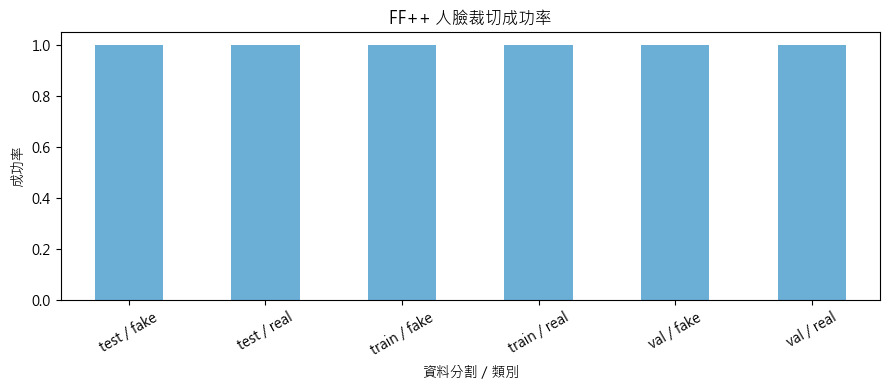

In [10]:
if "summary" in globals() and not summary.empty:
    plot_df = summary.copy()
    plot_df["group"] = plot_df["split"] + " / " + plot_df["class_name"]

    ax = plot_df.plot(
        x="group",
        y="success_rate",
        kind="bar",
        figsize=(9, 4),
        color="#6BAED6",
        legend=False,
    )
    ax.set_title("FF++ 人臉裁切成功率")
    ax.set_xlabel("資料分割／類別")
    ax.set_ylabel("成功率")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


## 6. 裁切結果檢查

原本此處為隨機抽樣的裁切人臉預覽圖，因 FaceForensics++ 授權條款限制影像再散布，已於公開版本移除。程式碼保留，可在本機重現。

In [11]:
if "final_df" not in globals() or final_df.empty:
    print("目前沒有成功裁切的人臉可供預覽。")
else:
    sample_count = min(12, len(final_df))
    samples = final_df.sample(sample_count, random_state=42)

    columns = 4
    rows = math.ceil(sample_count / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, samples.iterrows()):
        image = cv2.imread(str(row["face_path"]))
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            ax.imshow(image)
        ax.set_title(
            f"{row['split']} / {row['class_name']}\n"
            f"conf={row['confidence']:.3f}"
        )
        ax.axis("off")

    for ax in axes[sample_count:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 輸出結果

32,000 張圖片中成功裁切 31,996 張，失敗 4 張（皆為未偵測到人臉）。Real 與 Fake 的成功率差距為 0.01%，遠低於 2% 的警戒線，代表偵測階段沒有對某一類產生系統性偏誤。

`face_manifest.csv` 保留原始影片、官方分割、類別、偵測信心值與裁切框座標。後續 03、05、06 皆直接讀取這份清單。